# Chess Evaluations

Dataset: https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations/data

In [1]:
import pandas as pd
import numpy as np
import chess
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
def count_pieces(fen):
    board = chess.Board(fen)
    white = sum(1 for p in board.piece_map().values() if p.color)
    black = sum(1 for p in board.piece_map().values() if not p.color)
    return white, black

In [3]:
DATA_FILE = "data/chessData.csv"

df = pd.read_csv(DATA_FILE, nrows=10_000)

df["WhitePieces"], df["BlackPieces"] = zip(*df["FEN"].apply(count_pieces))
df["Evaluation"] = df["Evaluation"].astype(str).str.replace(r"[^0-9\-\.]", "", regex=True)
df["Evaluation"] = pd.to_numeric(df["Evaluation"], errors="coerce")

df["Scoring"] = np.clip(df["Evaluation"], -1000, 1000)

X = df[["WhitePieces", "BlackPieces"]]
y = df["Scoring"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
def sign_accuracy(y_true, y_pred):
    true_sign = np.sign(y_true)
    pred_sign = np.sign(y_pred)

    true_sign[true_sign == 0] = 1
    pred_sign[pred_sign == 0] = 1

    correct = np.sum(true_sign == pred_sign)
    return correct / len(y_true)

def sign_recall(y_true, y_pred, positive=True):
    true_sign = np.sign(y_true)
    pred_sign = np.sign(y_pred)
    true_sign[true_sign == 0] = 1
    pred_sign[pred_sign == 0] = 1

    if positive:
        mask = true_sign > 0
    else:
        mask = true_sign < 0

    if np.sum(mask) == 0:
        return np.nan
    return np.sum(pred_sign[mask] == true_sign[mask]) / np.sum(mask)

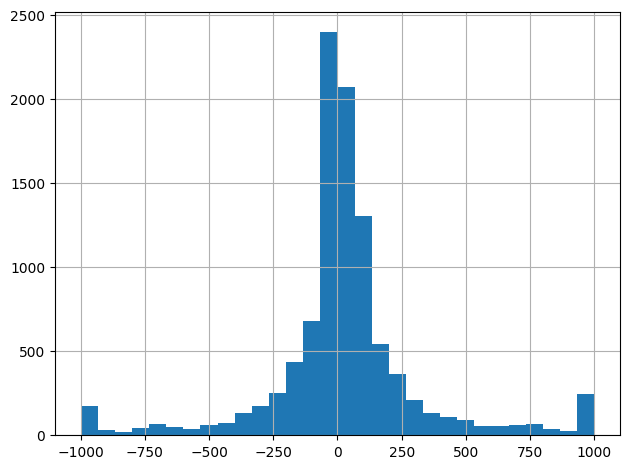

In [5]:
df["Scoring"].hist(bins=30)
plt.tight_layout()
plt.show()

Mean Squared Error: 132831.185
Sign accuracy: 0.6705
Positive sign recall: 0.967741935483871
Negative sign recall: 0.18552631578947368


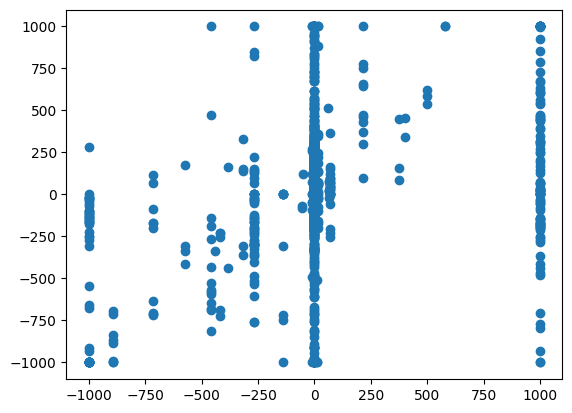

In [6]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
acc = sign_accuracy(y_test, y_pred)
recall_pos = sign_recall(y_test, y_pred, positive=True)
recall_neg = sign_recall(y_test, y_pred, positive=False)

print("Mean Squared Error:", mse)
print("Sign accuracy:", acc)
print("Positive sign recall:", recall_pos)
print("Negative sign recall:", recall_neg)

plt.scatter(y_pred, y_test)
plt.show()

Mean Squared Error: 85817.56976630712
Sign accuracy: 0.6625
Positive sign recall: 0.8629032258064516
Negative sign recall: 0.3355263157894737


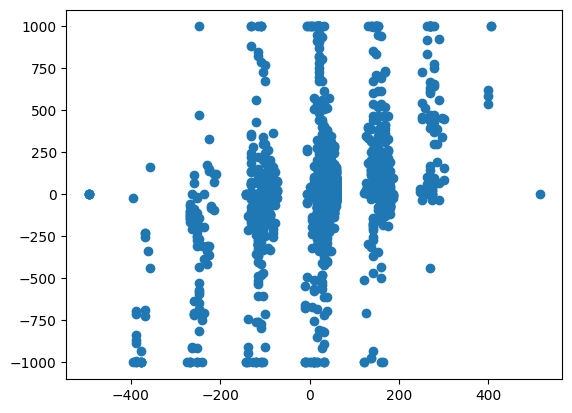

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
acc = sign_accuracy(y_test, y_pred)
recall_pos = sign_recall(y_test, y_pred, positive=True)
recall_neg = sign_recall(y_test, y_pred, positive=False)

print("Mean Squared Error:", mse)
print("Sign accuracy:", acc)
print("Positive sign recall:", recall_pos)
print("Negative sign recall:", recall_neg)

plt.scatter(y_pred, y_test)
plt.show()